<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1000, 1000)
Data Type: float64

First 5 Values:
[[   0.          1.001001    2.002002 ...  997.997998  998.998999
  1000.      ]
 [   0.          1.001001    2.002002 ...  997.997998  998.998999
  1000.      ]
 [   0.          1.001001    2.002002 ...  997.997998  998.998999
  1000.      ]
 [   0.          1.001001    2.002002 ...  997.997998  998.998999
  1000.      ]
 [   0.          1.001001    2.002002 ...  997.997998  998.998999
  1000.      ]]

FINAL Q-TABLE
                     Decrease    Maintain    Increase
Water Level State                                    
0                   79.511532   91.597942   99.999666
1                   79.956259   91.973955  100.000000
2                   79.999998   91.999999  100.000000
3                   88.000000  100.000000   88.000000
4                   88.000000  100.000000   88.000000
5                   88.000000  100.000000   88.000000
6                   88.000000  100.000000   88.000000
7                  100.000000

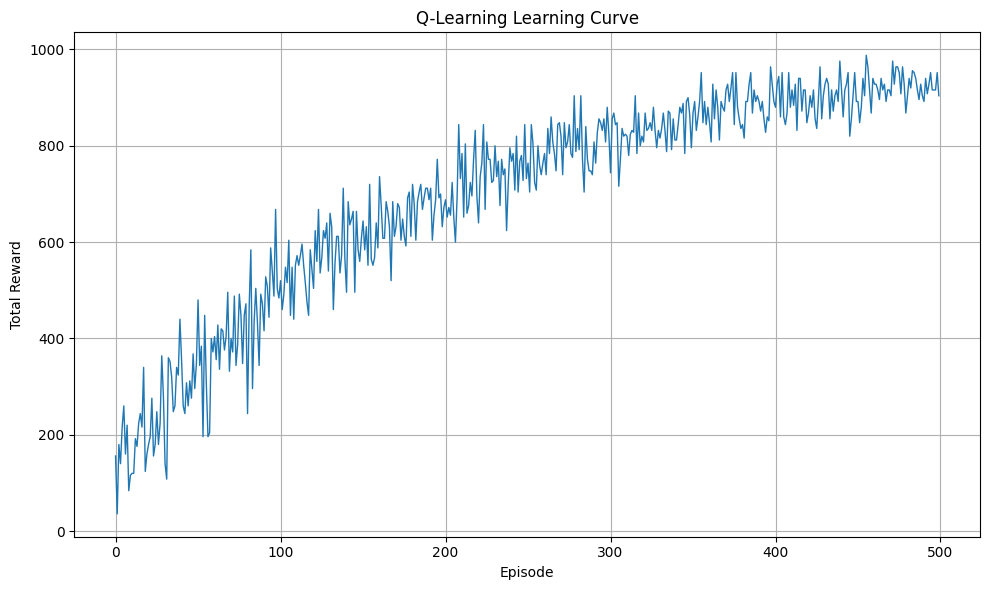

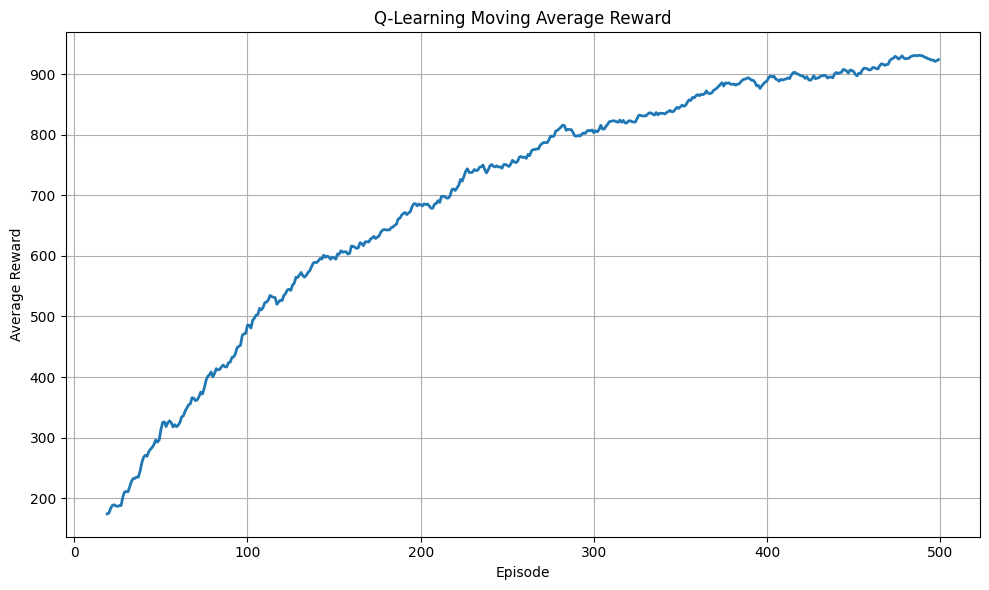

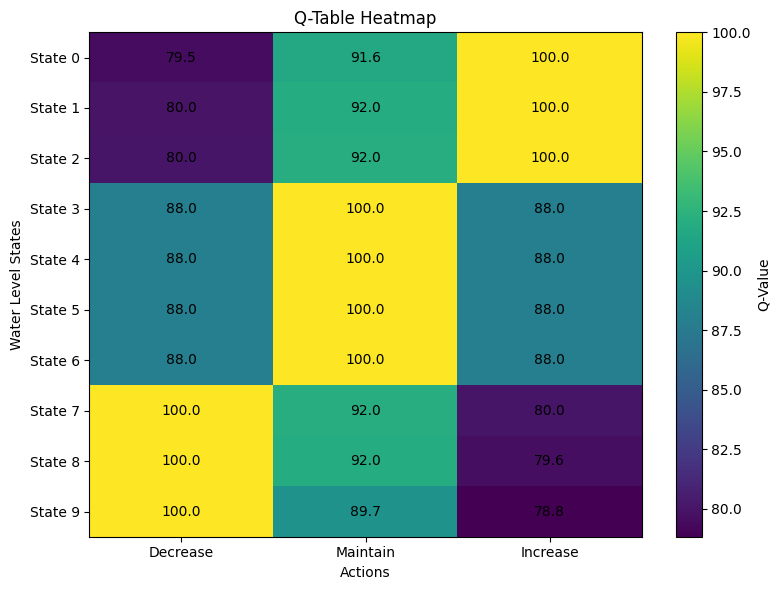

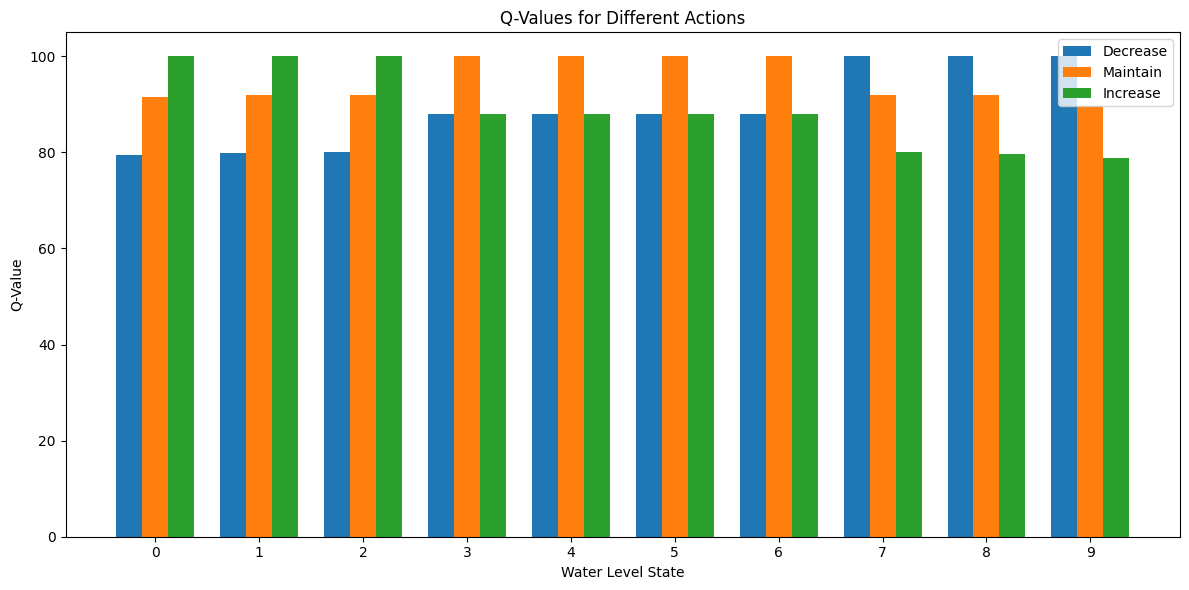

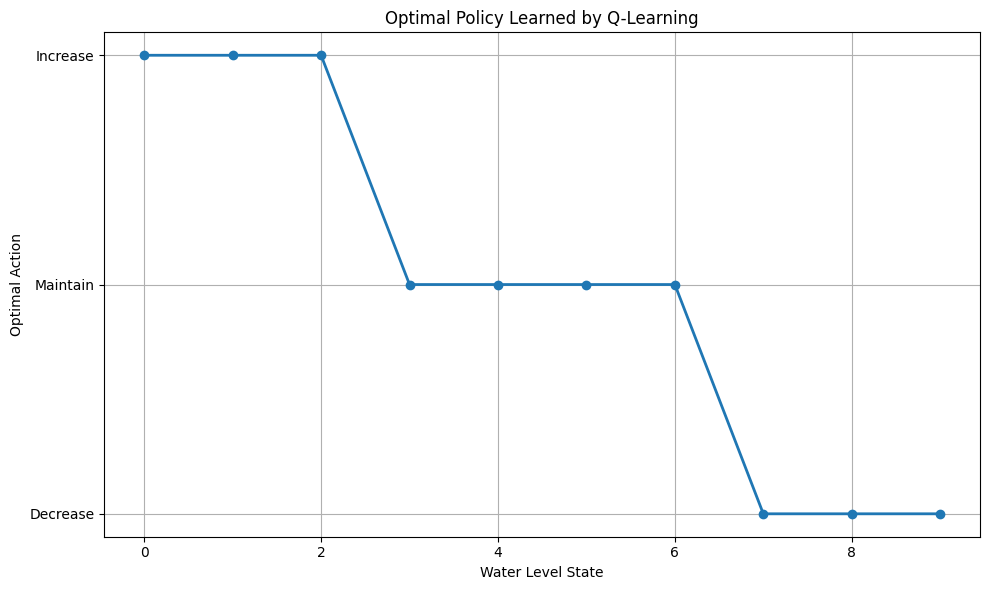

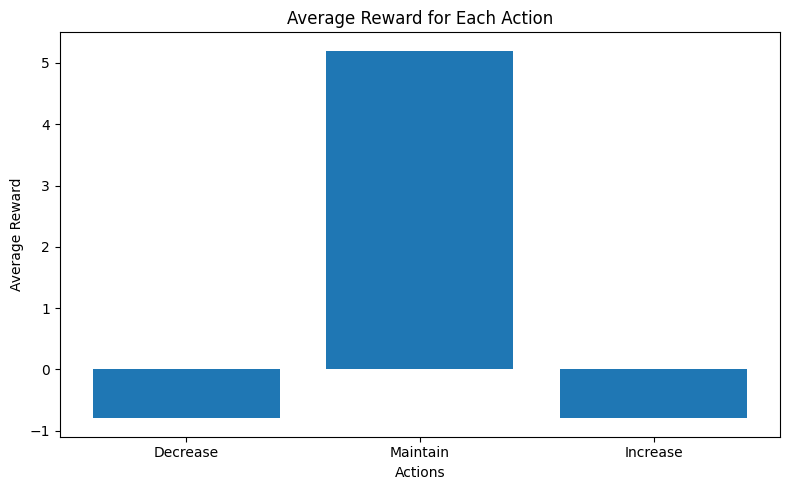


Q-table saved as: q_learning_water_results.csv


In [4]:
# ============================================================
# Q-LEARNING - WATER DATASET
# REINFORCEMENT LEARNING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATASET
# ============================================================

data = np.load(
    "/content/default_X_water.npy",
    allow_pickle=True
)

print("Dataset Shape:", data.shape)
print("Data Type:", data.dtype)

print("\nFirst 5 Values:")
print(data[:5])


# ============================================================
# 2. CONVERT DATA TO NUMERIC
# ============================================================

data = np.asarray(data, dtype=float)

# Remove rows containing NaN or infinity
data = data[
    np.isfinite(data).all(axis=1)
]


# ============================================================
# 3. CREATE WATER LEVEL STATES
# ============================================================

# If dataset contains multiple features,
# use the first feature as water-level information.

water_values = data[:, 0]


# Normalize values between 0 and 100
minimum = water_values.min()
maximum = water_values.max()

if maximum != minimum:

    water_level = (
        (water_values - minimum)
        / (maximum - minimum)
    ) * 100

else:

    water_level = np.zeros(
        len(water_values)
    )


# ============================================================
# 4. DISCRETIZE INTO STATES
# ============================================================

# 10 states:
# 0 = Very Low
# 1 = Low
# ...
# 9 = Very High

num_states = 10

states = np.clip(
    (water_level / 100 * num_states).astype(int),
    0,
    num_states - 1
)


# ============================================================
# 5. DEFINE ACTIONS
# ============================================================

# 0 = Decrease water release
# 1 = Maintain current level
# 2 = Increase water release

num_actions = 3

action_names = [
    "Decrease",
    "Maintain",
    "Increase"
]


# ============================================================
# 6. CREATE Q-TABLE
# ============================================================

Q = np.zeros(
    (num_states, num_actions)
)


# ============================================================
# 7. Q-LEARNING PARAMETERS
# ============================================================

alpha = 0.1       # Learning rate
gamma = 0.9       # Discount factor
epsilon = 1.0     # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 500


# ============================================================
# 8. REWARD FUNCTION
# ============================================================

def get_reward(state, action):

    # Very low water level
    if state <= 2:

        if action == 2:
            return 10

        elif action == 1:
            return 2

        else:            return -10


    # Very high water level
    elif state >= 7:

        if action == 0:
            return 10

        elif action == 1:
            return 2

        else:            return -10


    # Normal water level
    else:

        if action == 1:
            return 10

        else:            return -2


# ============================================================
# 9. Q-LEARNING TRAINING
# ============================================================

episode_rewards = []
episode_steps = []

for episode in range(episodes):

    # Random starting state
    state = np.random.randint(
        0,
        num_states
    )

    total_reward = 0
    steps = 0

    for step in range(100):

        # ----------------------------------------------------
        # Epsilon-Greedy Action Selection
        # ----------------------------------------------------

        if np.random.random() < epsilon:

            action = np.random.randint(
                0,
                num_actions
            )

        else:

            action = np.argmax(
                Q[state]
            )


        # ----------------------------------------------------
        # Calculate Reward
        # ----------------------------------------------------

        reward = get_reward(
            state,
            action
        )


        # ----------------------------------------------------
        # Determine Next State
        # ----------------------------------------------------

        if action == 2:

            next_state = min(
                state + 1,
                num_states - 1
            )

        elif action == 0:

            next_state = max(
                state - 1,
                0
            )

        else:

            next_state = state


        # ----------------------------------------------------
        # Q-Learning Update
        # ----------------------------------------------------

        Q[state, action] = Q[state, action] + alpha * (
            reward
            + gamma * np.max(Q[next_state])
            - Q[state, action]
        )


        total_reward += reward

        state = next_state

        steps += 1


    # --------------------------------------------------------
    # Reduce Exploration
    # --------------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    episode_rewards.append(
        total_reward
    )

    episode_steps.append(
        steps
    )


# ============================================================
# 10. DISPLAY Q-TABLE
# ============================================================

q_table = pd.DataFrame(
    Q,
    columns=action_names
)

q_table.index.name = "Water Level State"

print("\n==========================================")
print("FINAL Q-TABLE")
print("==========================================")

print(q_table)


# ============================================================
# 11. BEST ACTION FOR EACH STATE
# ============================================================

best_actions = np.argmax(
    Q,
    axis=1
)

print("\n==========================================")
print("OPTIMAL POLICY")
print("==========================================")

for state in range(num_states):

    print(
        f"State {state}: "
        f"{action_names[best_actions[state]]}"
    )


# ============================================================
# 12. VISUALIZATION 1
#     LEARNING CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    episode_rewards,
    linewidth=1
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Total Reward"
)

plt.title(
    "Q-Learning Learning Curve"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 13. VISUALIZATION 2
#     MOVING AVERAGE REWARD
# ============================================================

window = 20

moving_average = pd.Series(
    episode_rewards
).rolling(
    window
).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    moving_average,
    linewidth=2
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "Q-Learning Moving Average Reward"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 14. VISUALIZATION 3
#     Q-VALUE HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    Q,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Q-Value"
)

plt.xticks(
    range(num_actions),
    action_names
)

plt.yticks(
    range(num_states),
    [f"State {i}" for i in range(num_states)]
)

plt.xlabel(
    "Actions"
)

plt.ylabel(
    "Water Level States"
)

plt.title(
    "Q-Table Heatmap"
)

for i in range(num_states):

    for j in range(num_actions):

        plt.text(
            j,
            i,
            f"{Q[i, j]:.1f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()


# ============================================================
# 15. VISUALIZATION 4
#     STATE-ACTION BAR CHART
# ============================================================

plt.figure(figsize=(12, 6))

x = np.arange(num_states)

width = 0.25

for action in range(num_actions):

    plt.bar(
        x + action * width,
        Q[:, action],
        width,
        label=action_names[action]
    )

plt.xlabel(
    "Water Level State"
)

plt.ylabel(
    "Q-Value"
)

plt.title(
    "Q-Values for Different Actions"
)

plt.xticks(
    x + width,
    range(num_states)
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 16. VISUALIZATION 5
#     OPTIMAL POLICY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(num_states),
    best_actions,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Water Level State"
)

plt.ylabel(
    "Optimal Action"
)

plt.title(
    "Optimal Policy Learned by Q-Learning"
)

plt.yticks(
    range(num_actions),
    action_names
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 17. VISUALIZATION 6
#     REWARD BY ACTION
# ============================================================

average_rewards = []

for action in range(num_actions):

    rewards = []

    for state in range(num_states):

        rewards.append(
            get_reward(
                state,
                action
            )
        )

    average_rewards.append(
        np.mean(rewards)
    )


plt.figure(figsize=(8, 5))

plt.bar(
    action_names,
    average_rewards
)

plt.xlabel(
    "Actions"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "Average Reward for Each Action"
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. SAVE Q-TABLE
# ============================================================

q_table.to_csv(
    "q_learning_water_results.csv"
)

print(
    "\nQ-table saved as: "
    "q_learning_water_results.csv"
)
